# Janis + Agilent E4980A Control Notebook

Interactive notebook for impedance spectroscopy measurements with temperature and bias control.

**Features:**
- ✅ Clean utility functions for stacked measurements
- ✅ Fixed temperature with bias sweep
- ✅ Temperature sweep (frequency sweep at each temperature)
- ✅ Full temperature + bias sweep (frequency sweep at each temp/bias combination)

**Setup required:**
1. Run `pip install -e .` in `instrument-interfaces/` directory (one time only)
2. Check GPIB addresses match your hardware (see cell 2)
3. Run cells sequentially (Shift+Enter)

In [8]:
# Imports
from nfoinstruments.drivers import Janis, E4890A
from nfoinstruments.drivers.setup import MeasurementSetup
from nfoinstruments.procedures import (
    set_temperature_and_wait, 
    sweep_frequency_lcr, 
    set_bias_and_wait,
    load_measurement_files,
    plot_all_measurements,
    plot_measurement_comparison
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from pathlib import Path

# Counter for run numbering
run_count = 1

# Output
output_path = Path(r"C:\Users\F110216\Desktop\Data_Horatio\DR008")

In [9]:
# Initialize instruments
mm = MeasurementSetup()

# Connect to devices (update GPIB addresses if needed)
mm.connect_to_devices({
    'GPIB0::16::INSTR': Janis,
    'GPIB0::17::INSTR': E4890A
})

janis = mm.devices['GPIB0::16::INSTR']
lcr = mm.devices['GPIB0::17::INSTR']

print(f"✓ Connected - Janis: {janis.temperature:.1f} K, LCR: Ready")

['GPIB0::15::INSTR', 'GPIB0::18::INSTR', 'GPIB0::22::INSTR', 'GPIB0::16::INSTR', 'GPIB0::17::INSTR']
{'_alc_enabled': True,
 '_averages': 1,
 '_bias': 0,
 '_frequency': 100,
 '_measurement_time': <MeasurementTime.MEDIUM: 'MED'>,
 '_measurement_type': <MeasurementType.RX: 'RX'>,
 '_signal_amplitude': 1,
 '_signal_type': <SignalType.VOLTAGE: 2>,
 'address': 'GPIB0::17::INSTR',
 'measurement_timeout': 10,
 'resource': <'GPIBInstrument'('GPIB0::17::INSTR')>}
✓ Connected - Janis: 10.0 K, LCR: Ready


In [12]:
# Configure LCR meter
lcr.measurement_type = E4890A.MeasurementType.ZTD  # Impedance magnitude & phase
lcr.measurement_time = E4890A.MeasurementTime.LONG
lcr.signal_amplitude = 0.08  # 50 mV
lcr.averages = 5
lcr.bias = 0.0

print(f"✓ LCR configured: {lcr.measurement_type.name}, {lcr.signal_amplitude}V, {lcr.averages} avg")

✓ LCR configured: ZTD, 0.08V, 5 avg


In [13]:
# Define frequency sweep points
frequency_points = np.round(
    np.logspace(np.log10(20), np.log10(2_000_000), num=500), 
    decimals=2
)

print(f"✓ Frequency sweep: {len(frequency_points)} points from {frequency_points[0]} Hz to {frequency_points[-1]} Hz")

✓ Frequency sweep: 500 points from 20.0 Hz to 2000000.0 Hz


In [20]:
print (output_path / f"somestring/inhere")

C:\Users\F110216\Desktop\Data_Horatio\DR008\somestring\inhere


---
## Option 1: Single Temperature Measurement

In [ ]:
# Single temperature measurement
target_temp = 10  # K

# Set temperature and wait for stability (with extra settling time)
actual_temp = set_temperature_and_wait(janis, target_temp, extra_settle_time=30, verbose=True)

# Filename format for your data import
filename = output_path / f"run{run_count:03d}_temp_{actual_temp:.0f}.csv"
print(f"\nMeasuring to: {filename}")

with open(filename, "w") as f:
    f.write("# time,bias,frequency,NA,Z,theta\n")
    sweep_frequency_lcr(janis, lcr, frequency_points, f, verbose=True)

run_count += 1
print(f"\n✓ Complete! Next run: {run_count}")

Setting temperature to 10 K...
Waiting for temperature stability...

✓ Temperature stable at 10.00 K
Additional 30s settling time...

Measuring to: data/run001_temp_10.csv
  Progress: 20/500 points
  Progress: 40/500 points
  Progress: 60/500 points
  Progress: 80/500 points
  Progress: 100/500 points
  Progress: 120/500 points
  Progress: 140/500 points
  Progress: 160/500 points
  Progress: 180/500 points
  Progress: 200/500 points
  Progress: 220/500 points
  Progress: 240/500 points
  Progress: 260/500 points
  Progress: 280/500 points
  Progress: 300/500 points
  Progress: 320/500 points
  Progress: 340/500 points
  Progress: 360/500 points
  Progress: 380/500 points
  Progress: 400/500 points
  Progress: 420/500 points
  Progress: 440/500 points
  Progress: 460/500 points
  Progress: 480/500 points
  Progress: 500/500 points
  ✓ Frequency sweep complete (500 points)

✓ Complete! Next run: 2


---
## Option 2: Temperature Sweep

In [ ]:
# Timing
start = time.time()

# Temperature sweep (multiple temperatures)
temp_points = list(range(10,5,310)) + [10]  # K
print(temp_points)
for target_temp in temp_points:
    print(f"\n{'='*60}")
    print(f"Temperature: {target_temp} K")
    print('='*60)
    
    # Set temperature and wait for stability
    actual_temp = set_temperature_and_wait(janis, target_temp, extra_settle_time=60, verbose=True)
    
    # Filename format
    filename = output_path / f"run{run_count:03d}_temp_{actual_temp:.0f}.csv"
    print(f"\nMeasuring to: {filename}")
    
    with open(filename, "w") as f:
        f.write("# time,bias,frequency,NA,Z,theta\n")
        sweep_frequency_lcr(janis, lcr, frequency_points, f, verbose=True)
    
    run_count += 1
    print(f"✓ Run {run_count-1} complete!")

print(f"\n{'='*60}")
print(f"✓ Temperature sweep complete! Next run: {run_count}")
print('='*60)

# Timing
end = time.time()
elapsed = end - start
# convert seconds → h:m:s
hours, rem = divmod(elapsed, 3600)
minutes, seconds = divmod(rem, 60)

print(f"Elapsed time: {int(hours):02d}:{int(minutes):02d}:{seconds:05.2f}")

[10]

Temperature: 10 K
Setting temperature to 10 K...
Waiting for temperature stability...

✓ Temperature stable at 10.00 K
Additional 60s settling time...

Measuring to: C:\Users\F110216\Desktop\Data_Horatio\DR008\run001_temp_10.csv
  Progress: 20/500 points
  Progress: 40/500 points
  Progress: 60/500 points
  Progress: 80/500 points
  Progress: 100/500 points


---
## Option 3: Fixed Temperature, Bias Sweep

In [ ]:
# Fixed temperature, bias sweep
target_temp = 300  # K
bias_points = [-1.0, -0.5, 0.0, 0.5, 1.0]  # V

print(f"{'='*60}")
print(f"Fixed Temperature Bias Sweep: {target_temp} K")
print('='*60)

# Set temperature and wait for stability
actual_temp = set_temperature_and_wait(janis, target_temp, extra_settle_time=30, verbose=True)

# Loop over bias voltages
for bias in bias_points:
    print(f"\n  Bias: {bias:+.2f} V")
    
    # Set bias and wait for settling
    set_bias_and_wait(lcr, bias, settle_time=1.0)
    
    # Filename format
    filename = output_path / f"run{run_count:03d}_temp_{actual_temp:.0f}_bias_{bias:+.2f}.csv"
    
    with open(filename, "w") as f:
        f.write("# time,bias,frequency,NA,Z,theta\n")
        sweep_frequency_lcr(janis, lcr, frequency_points, f, verbose=True)
    
    print(f"  ✓ Saved: run{run_count:03d}")
    run_count += 1

print(f"\n{'='*60}")
print(f"✓ Bias sweep complete! Next run: {run_count}")
print('='*60)

---
## Option 4: Temperature Sweep with Bias Sweep at Each Temperature

In [ ]:
# Temperature + Bias sweep (stacked measurement)
temp_points = [300, 280, 260]  # K
bias_points = [-1.0, -0.5, 0.0, 0.5, 1.0]  # V

print(f"{'='*60}")
print(f"Temperature + Bias Sweep")
print(f"Temperatures: {temp_points}")
print(f"Bias points: {bias_points}")
print('='*60)

# Loop over temperatures
for target_temp in temp_points:
    print(f"\n{'='*60}")
    print(f"Temperature: {target_temp} K")
    print('='*60)
    
    # Set temperature and wait for stability
    actual_temp = set_temperature_and_wait(janis, target_temp, extra_settle_time=30, verbose=True)
    
    # Loop over bias voltages at this temperature
    for bias in bias_points:
        print(f"\n  Bias: {bias:+.2f} V")
        
        # Set bias and wait
        set_bias_and_wait(lcr, bias, settle_time=1.0)
        
        # Filename format
        filename = output_path / f"run{run_count:03d}_temp_{actual_temp:.0f}_bias_{bias:+.2f}.csv"
        
        with open(filename, "w") as f:
            f.write("# time,bias,frequency,NA,Z,theta\n")
            sweep_frequency_lcr(janis, lcr, frequency_points, f, verbose=True)
        
        print(f"  ✓ Saved: run{run_count:03d}")
        run_count += 1

print(f"\n{'='*60}")
print(f"✓ ALL MEASUREMENTS COMPLETE! Next run: {run_count}")
print('='*60)

## Plotting

In [ ]:
# Load all measurement files from data directory
import os

# Make sure data directory exists
#os.makedirs("data", exist_ok=True)

# Load all data files
datasets = load_measurement_files(output_path, pattern="run*.csv")

if datasets:
    print(f"✓ Loaded {len(datasets)} files:\n")
    for filename, df in datasets:
        bias_mean = df['bias'].mean()
        freq_range = f"{df['frequency'].min():.0f} - {df['frequency'].max():.0f}"
        print(f"  {filename}: {len(df)} points, Bias={bias_mean:.3f}V, Freq={freq_range} Hz")
    
    # Show latest file in detail
    latest_file, latest_df = datasets[-1]
    print(f"\n=== Latest File: {latest_file} ===")
    print(latest_df.head())
else:
    print("No data files found yet - run a measurement first!")

✓ Loaded 1 files:

  run001_temp_10.csv: 500 points, Bias=0.000V, Freq=20 - 2000000 Hz

=== Latest File: run001_temp_10.csv ===
           time  bias  frequency  NA           Z    theta
0  1.762447e+09   0.0      20.00  -1  30740200.0 -84.3216
1  1.762447e+09   0.0      20.47  -1  29392600.0 -85.2462
2  1.762447e+09   0.0      20.94  -1  28922900.0 -85.1409
3  1.762447e+09   0.0      21.43  -1  28163600.0 -85.1856
4  1.762447e+09   0.0      21.93  -1  27562100.0 -84.8744


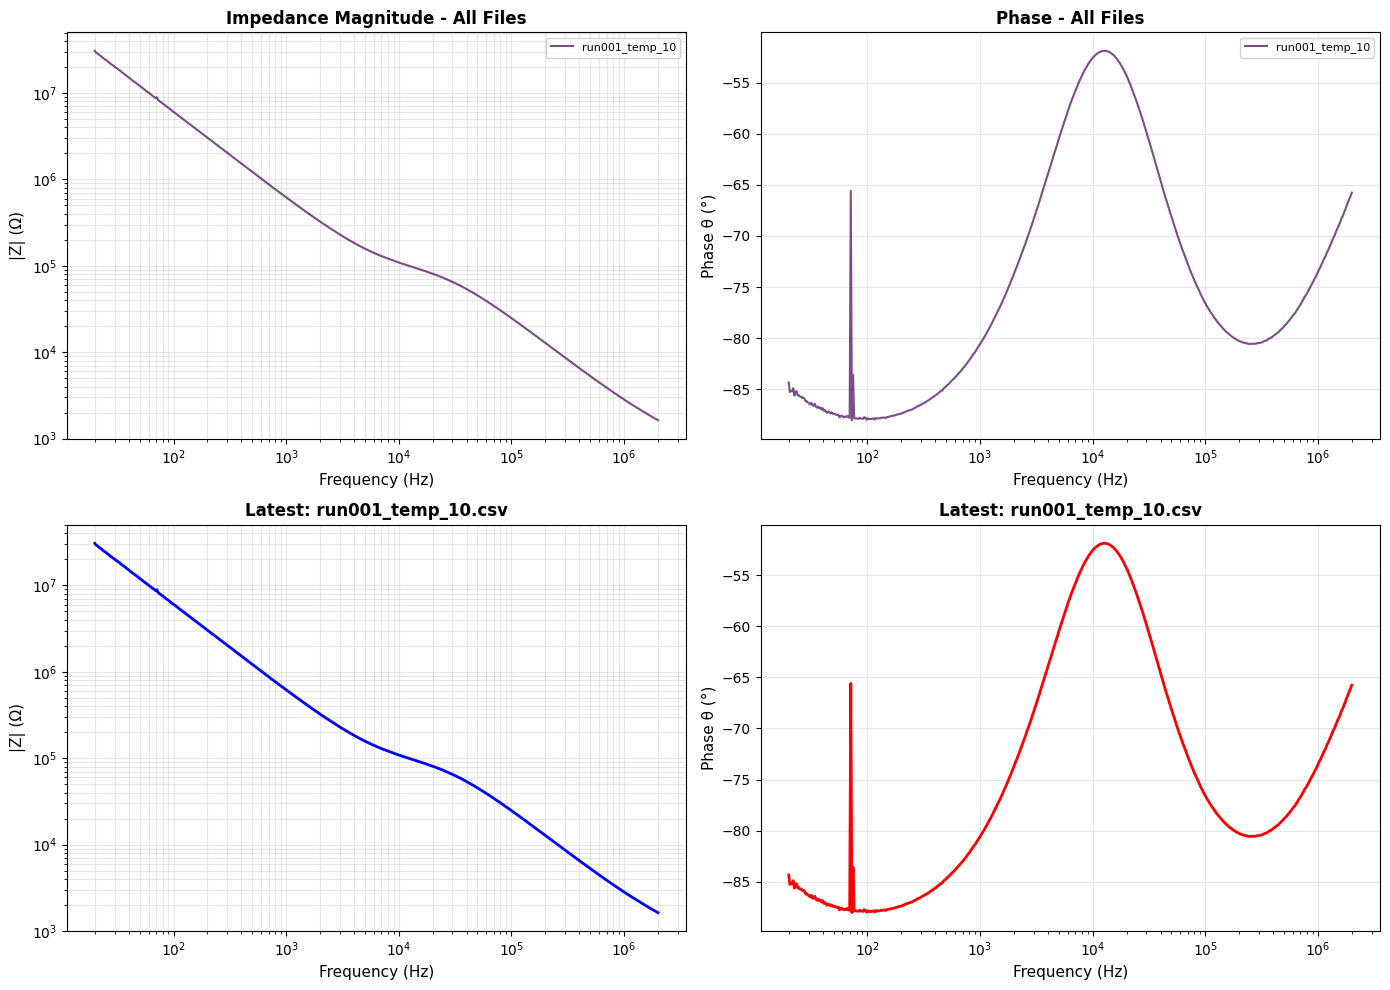


✓ Plotted 1 files from data


In [ ]:
# Plot all measurements together
# This creates a 2x2 plot:
# - Top: All files overlaid (impedance & phase)
# - Bottom: Latest file in detail

fig, axes, datasets = plot_all_measurements("data", pattern="run*.csv", figsize=(14, 10))

In [ ]:
# Plot specific files for detailed comparison
# Example: Compare first 3 files
# Uncomment and modify the list to select specific files

# plot_measurement_comparison("data", file_indices=[0, 1, 2], figsize=(14, 5))

---
## Quick Reference & Status Check

**Utility Functions Used:**
- `set_temperature_and_wait(controller, temp, extra_settle_time, verbose)` - Set temp and wait for stability
- `set_bias_and_wait(lcr, bias, settle_time)` - Set DC bias and wait
- `sweep_frequency_lcr(controller, lcr, frequencies, file, verbose)` - Perform frequency sweep

**Common Measurement Types:**
- `E4890A.MeasurementType.ZTD` - Impedance magnitude |Z| and phase θ
- `E4890A.MeasurementType.RX` - Resistance R and reactance X
- `E4890A.MeasurementType.CPD` - Parallel capacitance Cp and dissipation D

**Measurement Times:**
- `SHORT` - Fast, less accurate
- `MEDIUM` - Balanced (recommended)
- `LONG` - Slow, most accurate

In [ ]:
# Temperature + Bias sweep
temp_points = [300, 250, 200]  # K
bias_points = np.linspace(0, 1, 6)  # 0 to 1V in 0.2V steps

for target_temp in temp_points:
    print(f"\n{'='*50}")
    print(f"Temperature: {target_temp} K")
    print('='*50)
    
    janis.temperature_setpoint = target_temp
    print("Waiting for stability...")
    
    while not janis.temperature_stable:
        print(f"  Current: {janis.temperature:.1f} K")
        time.sleep(10)
    
    actual_temp = janis.temperature
    print(f"✓ Stable at {actual_temp:.1f} K")
    
    for bias in bias_points:
        print(f"\n  Bias: {bias:.2f} V")
        lcr.bias = bias
        time.sleep(0.5)
        
        # Filename format: run###_temp_###_bias_#.##.csv (matches your import regex)
        filename = f"C:/Users/F110216/Documents/DATA/Horatio/run{run_count}_temp_{actual_temp:.0f}_bias_{bias:.2f}.csv"
        
        with open(filename, "w") as f:
            f.write("# time,bias,frequency,NA,Z,theta\n")
            sweep_frequency_lcr(janis, lcr, frequency_points, f)
        
        print(f"  ✓ Saved: run{run_count}")
        run_count += 1

print(f"\n{'='*50}")
print(f"ALL DONE! Next run: {run_count}")
print('='*50)

In [ ]:
# Check current instrument status
print("=== Janis Status ===")
print(f"Current temperature: {janis.temperature:.2f} K")
print(f"Setpoint: {janis.temperature_setpoint} K")
print(f"Stable: {janis.temperature_stable}")
print(f"Max heater power: {janis.max_heater_power}%")

print("\n=== LCR Meter Status ===")
print(f"Measurement type: {lcr.measurement_type.name}")
print(f"Signal amplitude: {lcr.signal_amplitude} V")
print(f"Averages: {lcr.averages}")
print(f"Bias: {lcr.bias} V")
print(f"Current frequency: {lcr.frequency} Hz")

print(f"\n=== Run Counter ===")
print(f"Next run number: {run_count:03d}")

---
## 🔧 Diagnostics & Troubleshooting

In [ ]:
# Diagnose Janis controller status
# Run this if temperature isn't stabilizing

status = janis.get_controller_status()
print("=== Janis Controller Diagnostics ===")
for key, value in status.items():
    print(f"{key}: {value}")

print("\n=== Action: Force temperature control mode ===")
janis.temperature_setpoint = 10.0  # This now also sends MODE 2 command
print(f"✓ Setpoint updated to {janis.temperature_setpoint} K")
print(f"✓ Temperature control mode activated")
print(f"\nCurrent temp: {janis.temperature:.2f} K")
print(f"Waiting for heater to activate...")